# 📊 Customer Sales Analysis Dashboard

## 📔📚 Load modules

In [1]:
!python -m pip install -r requirements.txt

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Defaulting to user installation because normal site-packages is not writeable


## 📁 Dataset:

In [2]:
# create dataset
# run the file data_generate.py
!python data_generate.py

Data generation completed successfully.


## 📌 Tasks Checklist:

### 🔹 Data Preparation

In [3]:
# 1. Load the dataset and display first 5 rows.

df = pd.read_csv('customer_sales_data.csv')
df.head(5)

# 2. Show column names, data types, and shape of the dataset. 

df.info()

# 3. Convert Purchase_Date to datetime.
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'])

# 4.  Use NumPy to:
#   • Calculate average Total_Amount and Units_Purchased.
#   • Find the highest and lowest purchase amount.

avg_revenue = np.mean(df['Total_Amount'])
avg_units = np.mean(df['Units_Purchased'])

highest_purchase = np.max(df['Total_Amount'])
lowest_purchase = np.min(df['Total_Amount'])

numpy_summary = pd.DataFrame({
    'Average Revenue': [avg_revenue],
    'Average Units': [avg_units],
    'Highest Purchase': [highest_purchase],
    'Lowest Purchase': [lowest_purchase]
})

numpy_summary

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer_ID       510 non-null    object 
 1   Gender            510 non-null    object 
 2   Age               510 non-null    int64  
 3   Region            510 non-null    object 
 4   Product_Category  510 non-null    object 
 5   Units_Purchased   510 non-null    int64  
 6   Price_Per_Unit    485 non-null    float64
 7   Purchase_Date     510 non-null    object 
 8   Total_Amount      485 non-null    float64
dtypes: float64(2), int64(2), object(5)
memory usage: 36.0+ KB


,Average Revenue,Average Units,Highest Purchase,Lowest Purchase
0,715.376268,3.603922,7172.58,10.38


### 🔹 Data Cleaning

In [4]:
df.isna().sum()

Customer_ID          0
Gender               0
Age                  0
Region               0
Product_Category     0
Units_Purchased      0
Price_Per_Unit      25
Purchase_Date        0
Total_Amount        25
dtype: int64

In [5]:
df[["Price_Per_Unit", "Total_Amount"]] = df[["Price_Per_Unit", "Total_Amount"]].fillna(df[["Price_Per_Unit", "Total_Amount"]].mean())

df.isna().sum()

Customer_ID         0
Gender              0
Age                 0
Region              0
Product_Category    0
Units_Purchased     0
Price_Per_Unit      0
Purchase_Date       0
Total_Amount        0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(10)

In [7]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

### 🔹 Data Analysis

In [8]:
# 5. Group total sales by:
# • Gender
# • Region
# • Product Category

grouped_sales = df.groupby(['Gender', 'Region', 'Product_Category'])['Total_Amount'].sum().reset_index()

# 6.  Show month-wise or weekly total purchases using Purchase_Date.
month_df = df["Purchase_Date"].dt.month
week_df = df["Purchase_Date"].dt.isocalendar().week

month_map = {i: month_name for i, month_name in enumerate([
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
], 1)}

week_map = {i: f"Week {i}" for i in range(1, 53)}

def safe_week_map(week_num):
    return week_map.get(week_num, f"Week {week_num}")

monthly_sales = df.groupby(month_df.map(month_map))["Total_Amount"].sum().rename("Total_Revenue").reset_index()
print("Monthly sales columns:", monthly_sales.columns.tolist())

monthly_sales.columns = ['Month', 'Total_Revenue']
monthly_sales['Month'] = pd.Categorical(monthly_sales['Month'], categories=[
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
], ordered=True)
monthly_sales = monthly_sales.sort_values('Month').reset_index(drop=True)

weekly_sales = df.groupby(week_df.map(safe_week_map))["Total_Amount"].sum().rename("Total_Revenue").reset_index()
print("Weekly sales columns:", weekly_sales.columns.tolist())

weekly_sales.columns = ['Week', 'Total_Revenue']
weekly_sales['Week'] = pd.Categorical(weekly_sales['Week'], categories=[f"Week {i}" for i in range(1, 54)], ordered=True)
weekly_sales = weekly_sales.sort_values('Week').reset_index(drop=True)

monthly_sales, weekly_sales

Monthly sales columns: ['Purchase_Date', 'Total_Revenue']
Weekly sales columns: ['week', 'Total_Revenue']


(        Month  Total_Revenue
 0     January   25022.850000
 1    February   37423.016268
 2       March   22713.180000
 3       April   22614.558804
 4         May   41198.598804
 5        June   20527.052536
 6        July   23654.115072
 7      August   29461.898804
 8   September   40333.366268
 9     October   13437.612536
 10   November   35156.076268
 11   December   44457.141340,
        Week  Total_Revenue
 0    Week 1    6998.760000
 1    Week 2    7533.000000
 2    Week 3    5786.560000
 3    Week 4    4704.530000
 4    Week 5    3583.900000
 5    Week 6   12100.456268
 6    Week 7   18254.710000
 7    Week 8    1147.020000
 8    Week 9    2624.360000
 9   Week 10    6240.330000
 10  Week 11    2985.290000
 11  Week 12   10176.410000
 12  Week 13    3023.720000
 13  Week 14    3101.386268
 14  Week 15    1341.870000
 15  Week 16    6698.256268
 16  Week 17   11473.046268
 17  Week 18    6980.640000
 18  Week 19    4453.310000
 19  Week 20   13367.842536
 20  Week 21   15686.

### 🔹 Visualization

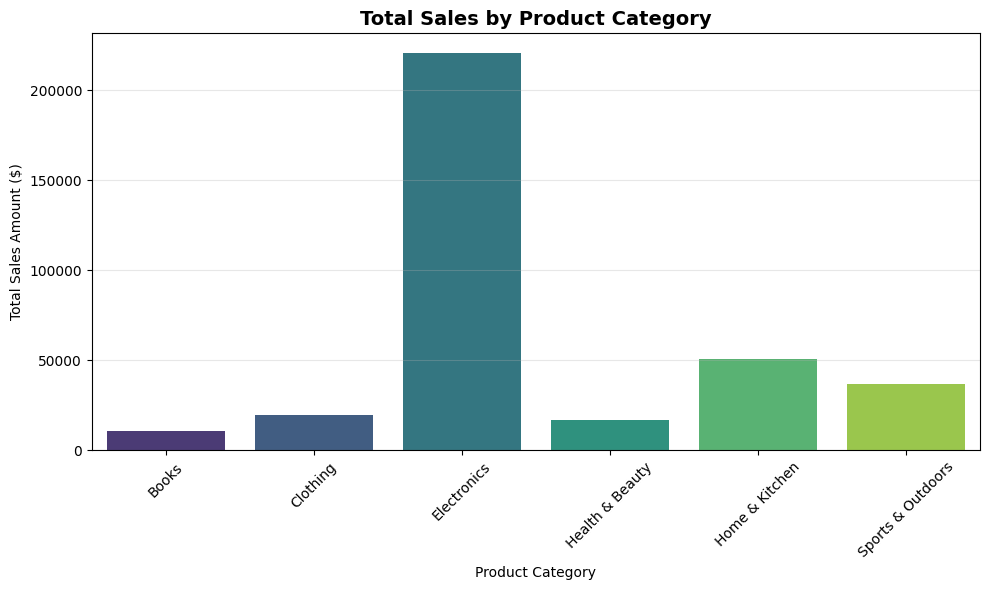

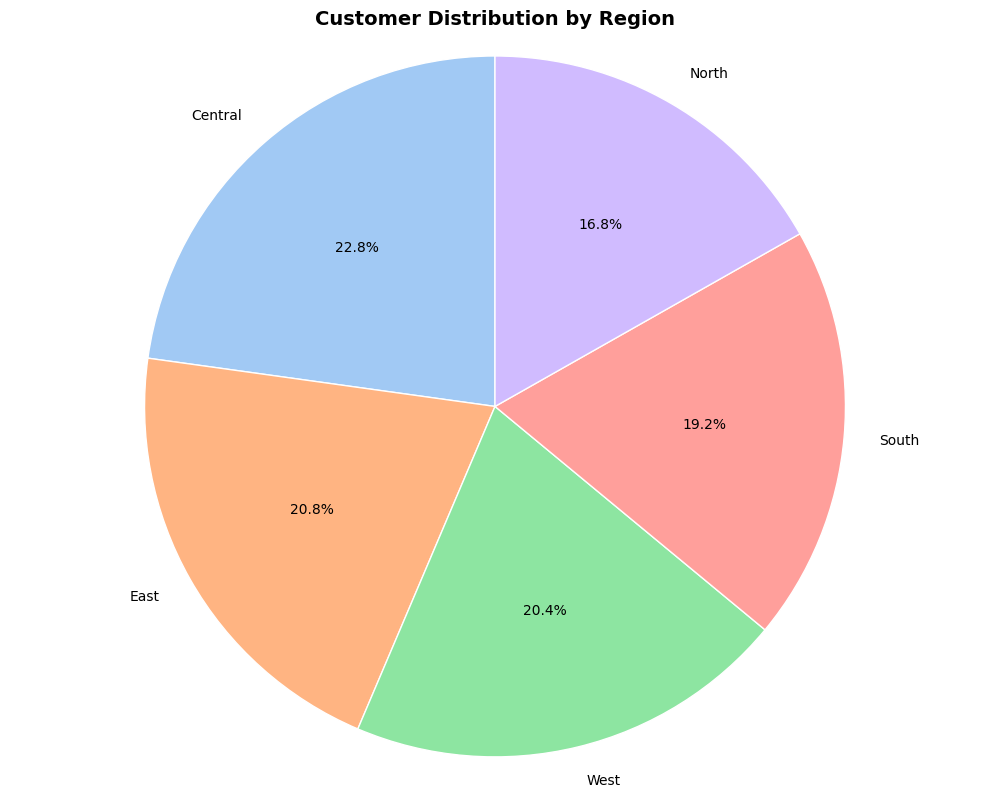

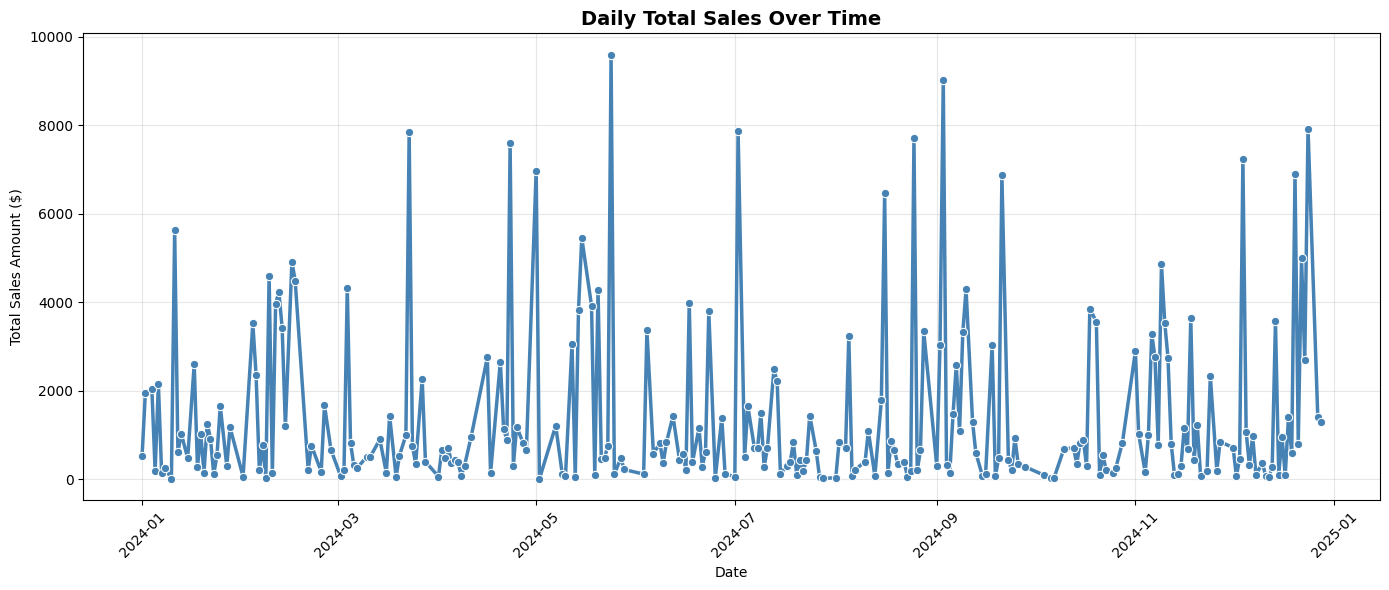

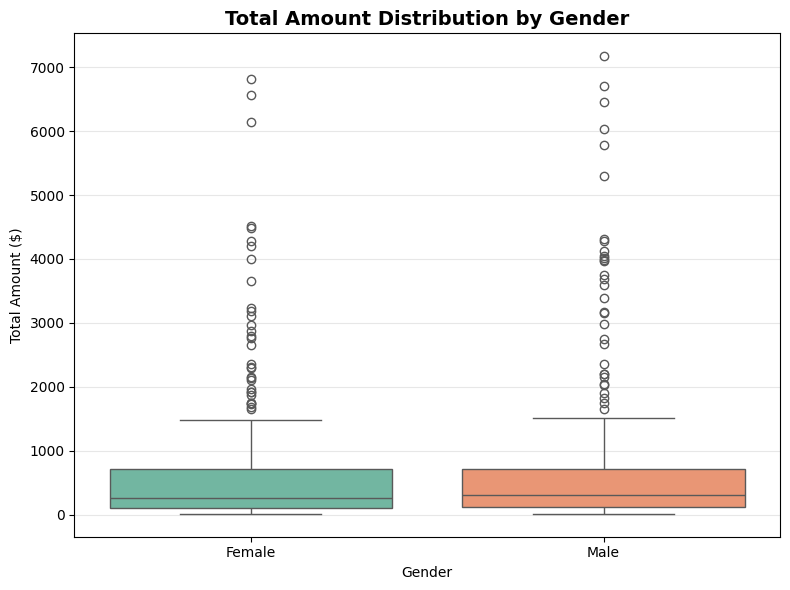

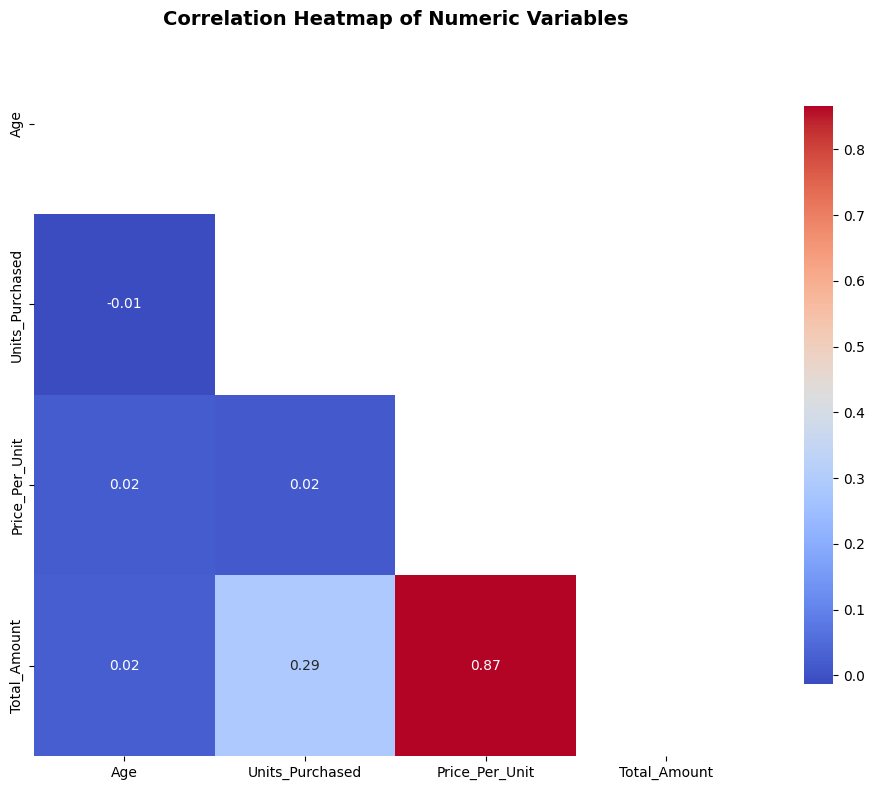

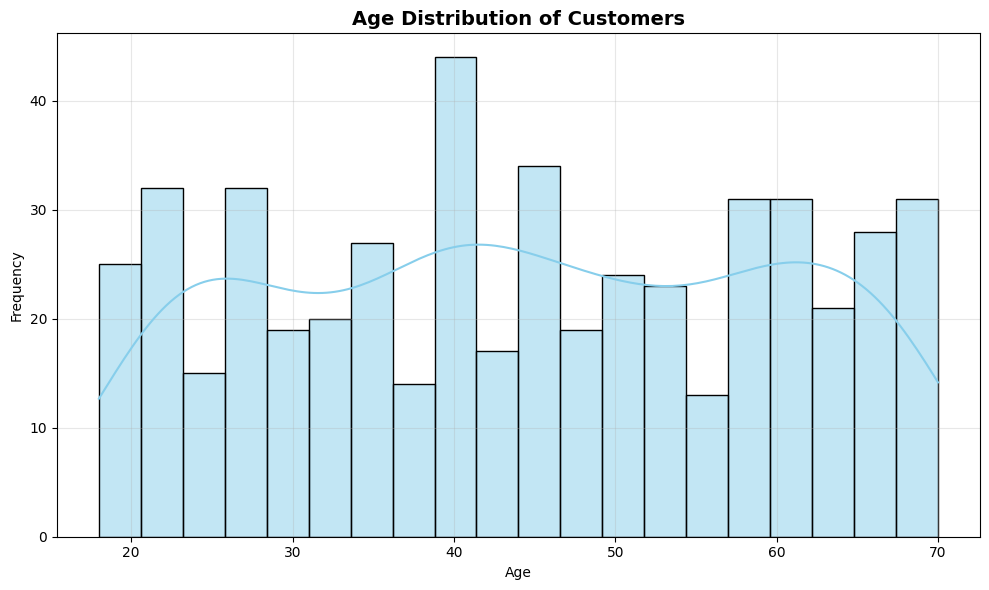

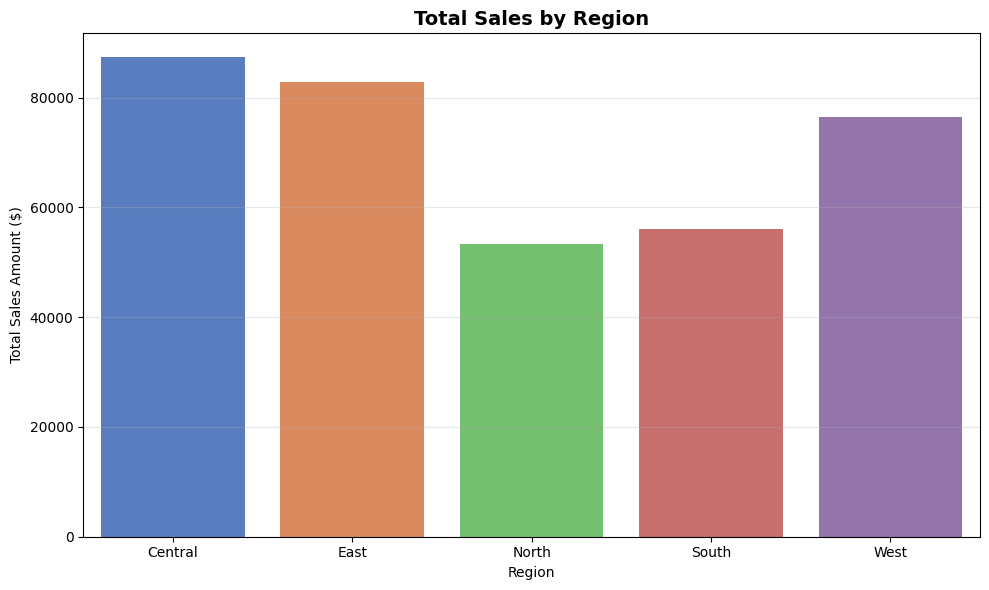

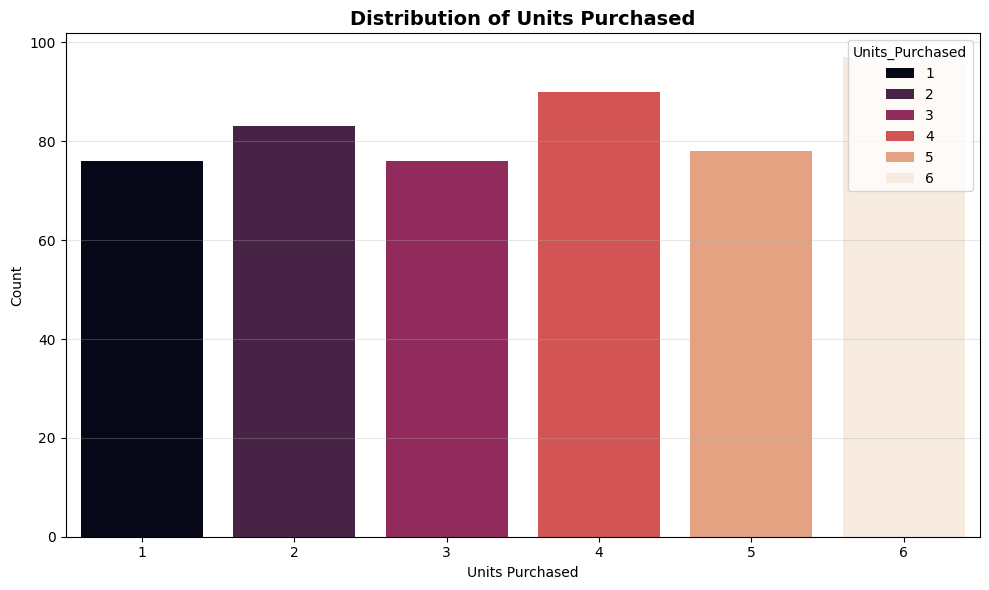

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 7. Plot a bar chart of total sales by Product Category.
plt.figure(figsize=(10, 6))
category_sales = df.groupby('Product_Category')['Total_Amount'].sum().reset_index()
sns.barplot(data=category_sales, x='Product_Category', y='Total_Amount', hue='Product_Category', palette='viridis', legend=False)
plt.title('Total Sales by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Product Category')
plt.ylabel('Total Sales Amount ($)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Plot a pie chart of customer distribution by Region.
plt.figure(figsize=(10, 8))
region_distribution = df['Region'].value_counts()
colors = sns.color_palette('pastel')
plt.pie(region_distribution.values, labels=region_distribution.index, autopct='%1.1f%%', 
        startangle=90, colors=colors, wedgeprops={'edgecolor': 'white', 'linewidth': 1})
plt.title('Customer Distribution by Region', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

# 9. Plot a line chart of daily total sales over time.
plt.figure(figsize=(14, 6))
daily_sales = df.groupby('Purchase_Date')['Total_Amount'].sum().reset_index()
daily_sales['Purchase_Date'] = pd.to_datetime(daily_sales['Purchase_Date'])
daily_sales = daily_sales.sort_values('Purchase_Date')

sns.lineplot(data=daily_sales, x='Purchase_Date', y='Total_Amount', marker='o', 
             linewidth=2.5, markersize=6, color='steelblue')
plt.title('Daily Total Sales Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Sales Amount ($)')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 10. Use Seaborn:
# • Create a box plot of Total_Amount by Gender.
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Gender', y='Total_Amount', hue='Gender', palette='Set2', legend=False)
plt.title('Total Amount Distribution by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Total Amount ($)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# • Create a heatmap of correlation between numeric columns.
plt.figure(figsize=(10, 8))
numeric_df = df[['Age', 'Units_Purchased', 'Price_Per_Unit', 'Total_Amount']].copy()
correlation_matrix = numeric_df.corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, mask=mask, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap of Numeric Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Additional improved visualizations:

# 11. Age distribution histogram
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', bins=20, kde=True, color='skyblue')
plt.title('Age Distribution of Customers', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 12. Sales by Region bar chart
plt.figure(figsize=(10, 6))
region_sales = df.groupby('Region')['Total_Amount'].sum().reset_index()
sns.barplot(data=region_sales, x='Region', y='Total_Amount', hue='Region', 
            palette='muted', legend=False)
plt.title('Total Sales by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Total Sales Amount ($)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 13. Units purchased distribution
plt.figure(figsize=(10, 6))
units_count = df['Units_Purchased'].value_counts().sort_index()
sns.barplot(x=units_count.index, y=units_count.values, hue=units_count.index, palette='rocket')
plt.title('Distribution of Units Purchased', fontsize=14, fontweight='bold')
plt.xlabel('Units Purchased')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()